## Блокнот с блоками кода для курса
[Stepik course](https://stepik.org/course/216086/info)

In [81]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
# запрос к БД для получения GMV, числа заказов
query = """
           SELECT date(date_created) as date_cr
           , SUM(price * quantity) as gmv_cr
           , COUNT(DISTINCT o.order_id) as orders_cr
           FROM sandbox.order_details od inner join sandbox.orders o 
           ON od.order_id = o.order_id 
           GROUP BY date(date_created);

        """

df = pd.read_sql_query(query, engine)
df.head(3)

,date_cr,gmv_cr,orders_cr
0,2017-01-05,396.90,32
1,2017-01-06,916.38,4
2,2017-01-07,1351.90,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557 entries, 0 to 556
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date_cr    557 non-null    object 
 1   gmv_cr     557 non-null    float64
 2   orders_cr  557 non-null    int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 13.2+ KB


In [15]:
# формат поля дата, обогащение месяцем заказа
df.date_cr = pd.to_datetime(df['date_cr'])
df['month_cr'] = df.date_cr.dt.to_period('M').dt.to_timestamp()
df.head(3)

,date_cr,gmv_cr,orders_cr,month_cr
0,2017-01-05,396.90,32,2017-01-01
1,2017-01-06,916.38,4,2017-01-01
2,2017-01-07,1351.90,4,2017-01-01


In [16]:
#расчет GMV, числа заказов, AOV по месяцам
df_monthly = df.groupby('month_cr', as_index=False).agg({'gmv_cr': 'sum', 'orders_cr': 'sum'})
df_monthly['aov_cr'] = df_monthly.gmv_cr / df_monthly.orders_cr
df_monthly.head(3)

,month_cr,gmv_cr,orders_cr
0,2017-01-01,112080.31,750
1,2017-02-01,227549.44,1606
2,2017-03-01,354646.41,2524


In [19]:
#расчет прироста GMV, числа заказов июнь/май 2018
(df_monthly.T[1:][17]/df_monthly.T[1:][16] - 1) * 100

gmv_cr      -12.195672
orders_cr     -9.51534
aov_cr       -2.962195
dtype: object

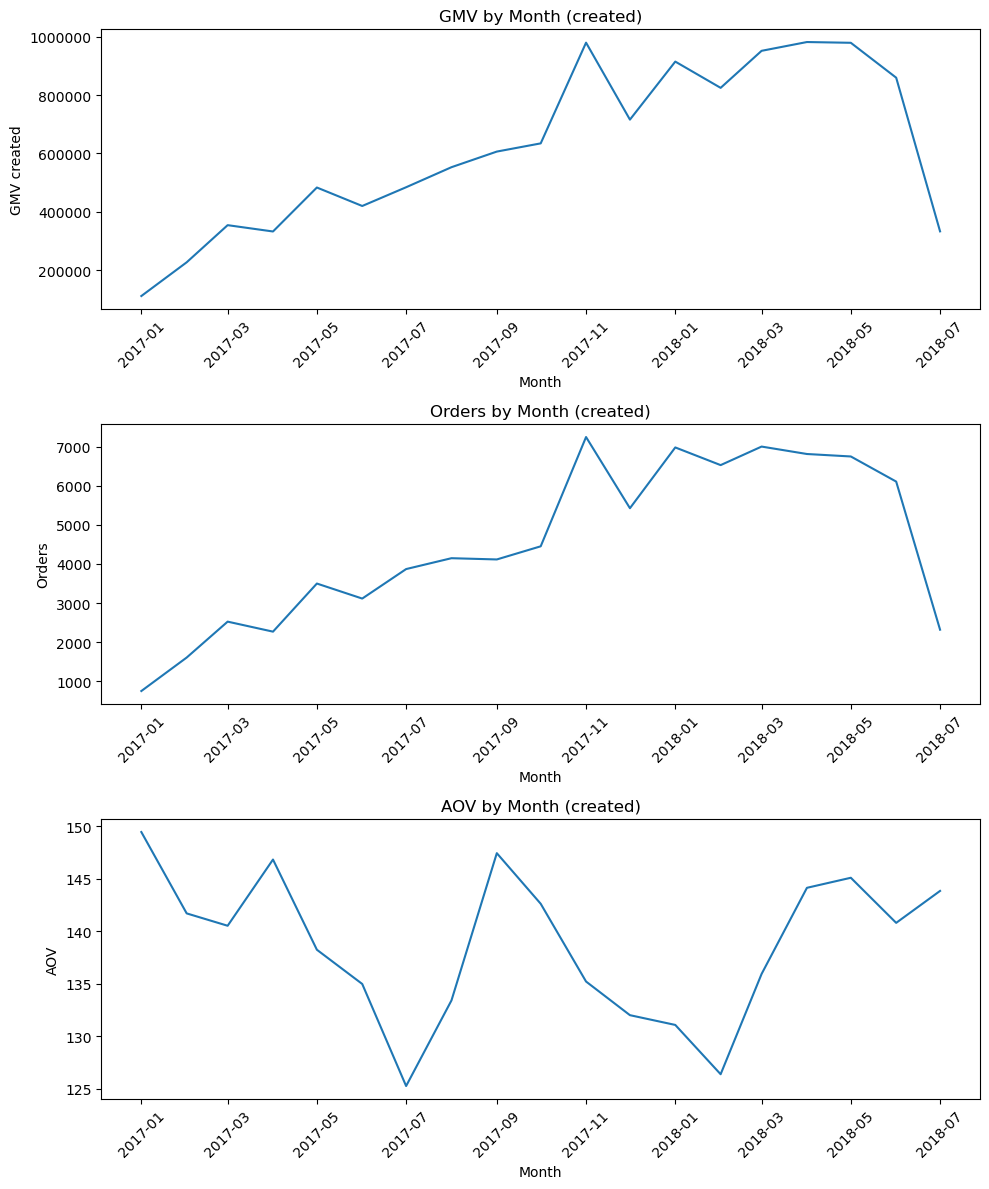

In [68]:
#GMV, заказы, AOV в разрезе по месяцам
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(df_monthly['month_cr'], df_monthly['gmv_cr'])
axes[0].set_xlabel('Month')
axes[0].set_ylabel('GMV created')
axes[0].set_title('GMV by Month (created)')

axes[0].tick_params(axis='x', labelrotation=45)
axes[0].ticklabel_format(axis='y', style='plain')

axes[1].plot(df_monthly['month_cr'], df_monthly['orders_cr'])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Orders')
axes[1].set_title('Orders by Month (created)')
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].ticklabel_format(axis='y', style='plain')

axes[2].plot(df_monthly['month_cr'], df_monthly['aov_cr'])
axes[2].set_xlabel('Month')
axes[2].set_ylabel('AOV')
axes[2].set_title('AOV by Month (created)')
axes[2].tick_params(axis='x', labelrotation=45)
axes[2].ticklabel_format(axis='y', style='plain')

plt.tight_layout()



In [65]:
#запрос MARGIN, GMV по дате оплаты заказа

query2 = """
           SELECT DATE(date_paid) as date_paid
           , SUM(price * quantity) as gmv_paid
           , SUM(price * quantity * commission) as margin_paid
           FROM sandbox.order_details od inner join sandbox.orders o
           on od.order_id = o.order_id 
           GROUP by DATE(date_paid);
        """


In [66]:
# коррекция даты, обогащение месяцем, неделей по дате создания заказа
df2 = pd.read_sql_query(query2, engine)
df2.date_paid = pd.to_datetime(df2.date_paid)
df2['month_paid'] = df2.date_paid.dt.to_period('M').dt.to_timestamp()
df2.head(3)

,date_paid,gmv_paid,margin_paid,month_paid
0,NaT,118862.72,30794.0094,NaT
1,2017-06-13,20607.31,5411.1759,2017-06-01
2,2017-08-24,18891.38,4561.2177,2017-08-01


In [67]:
#расчет GMV, маржи, % маржи от GMV по месяцам
df2_monthly = df2.groupby('month_paid', as_index=False).agg({'gmv_paid': 'sum', 'margin_paid': 'sum'})
df2_monthly['margin_%'] = round(df2_monthly.margin_paid / df2_monthly.gmv_paid * 100,1)
df2_monthly.head(3)

,month_paid,gmv_paid,margin_paid,margin_%
0,2017-01-01,82381.46,21244.7335,25.8
1,2017-02-01,215954.90,54319.5607,25.2
2,2017-03-01,369711.61,93925.7885,25.4


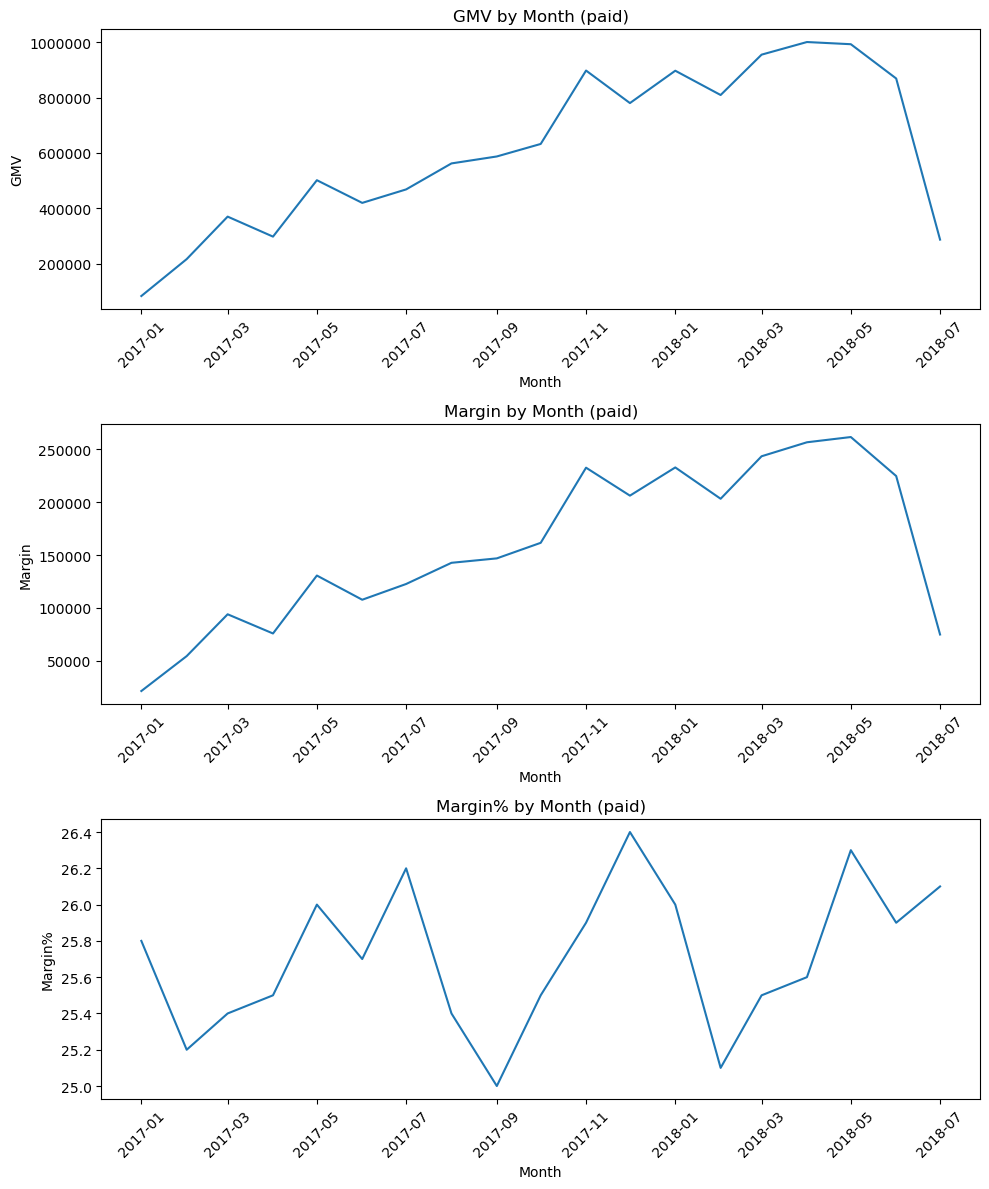

In [70]:
#GMV, заказы, AOV в разрезе по месяцам
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
axes[0].plot(df2_monthly['month_paid'], df2_monthly['gmv_paid'])
axes[0].set_xlabel('Month')
axes[0].set_ylabel('GMV')
axes[0].set_title('GMV by Month (paid)')

axes[0].tick_params(axis='x', labelrotation=45)
axes[0].ticklabel_format(axis='y', style='plain')

axes[1].plot(df2_monthly['month_paid'], df2_monthly['margin_paid'])
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Margin')
axes[1].set_title('Margin by Month (paid)')
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].ticklabel_format(axis='y', style='plain')

axes[2].plot(df2_monthly.month_paid, df2_monthly['margin_%'])
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Margin%')
axes[2].set_title('Margin% by Month (paid)')
axes[2].tick_params(axis='x', labelrotation=45)
axes[2].ticklabel_format(axis='y', style='plain')

plt.tight_layout()

In [71]:
# прирост маржи май-июнь 2018, на число %
(df2_monthly.T[17][2]/df2_monthly.T[16][2] - 1) * 100.1

-14.119647260453617

In [72]:
# изменение доли маржи от GMV мая-июнь, на число %
round(df2_monthly.T[17][3] - df2_monthly.T[16][3], 3)

-0.4

In [93]:
query3 = '''
    select category_name 
    , date(date_created) as date_created
    , SUM(price * quantity) as gmv_cr  
    FROM sandbox.order_details od inner join sandbox.orders o
    on od.order_id = o.order_id 
    group by  category_name, date(date_created)
    '''
df3 = pd.read_sql_query(query3, engine)
df3.date_created = pd.to_datetime(df3.date_created)
df3['month_created'] = df3.date_created.dt.to_period('M').dt.to_timestamp().dt.date

df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5469 entries, 0 to 5468
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   category_name  5469 non-null   object        
 1   date_created   5469 non-null   datetime64[ns]
 2   gmv_cr         5469 non-null   float64       
 3   month_created  5469 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 171.0+ KB


In [94]:
# GMV по категориям
df3_monthly = df3.groupby(['month_created', 'category_name'], as_index=False).agg({'gmv_cr': 'sum'})
#df3_monthly = df3.groupby(['month_created', 'category_name'], as_index=False).gmv_cr.sum()
df3_monthly.head()

,month_created,category_name,gmv_cr
0,2017-01-01,Automotive & Industrial,5732.99
1,2017-01-01,Baby Products,6217.88
2,2017-01-01,Electronics & Computers,12706.58
3,2017-01-01,Fashion & Accessories,10627.34
4,2017-01-01,Food & Beverages,42.82


In [95]:
# Сводная GMV по категориям/месяцам
df3_pivot = df3_monthly.pivot(index='category_name', columns='month_created', values='gmv_cr')
df3_pivot.head()

month_created,2017-01-01,2017-02-01,2017-03-01,2017-04-01,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01
category_name,,,,,,,,,,,,,,,,,,,
Automotive & Industrial,5732.99,16513.71,18085.63,18708.51,22163.20,33632.52,17993.44,26205.84,22207.92,35656.31,66059.91,55380.32,63659.36,73445.48,73260.03,82041.37,77817.29,86972.56,29726.53
Baby Products,6217.88,2872.58,3604.18,3980.45,9283.62,7864.74,15461.41,19762.33,23412.44,16497.50,21178.18,19943.18,30156.67,26046.24,41381.04,49801.91,33420.65,31076.12,8271.07
Electronics & Computers,12706.58,28903.85,52870.05,36855.17,67417.32,53657.05,61896.39,94490.26,125536.22,123891.86,133504.09,89287.60,134594.74,149754.54,148680.06,115311.19,108508.94,98825.51,40345.59
Fashion & Accessories,10627.34,16420.66,38305.29,35873.85,60670.25,45344.94,50937.89,53474.08,66957.86,82037.54,121620.07,89631.98,103245.57,81450.26,115354.70,111737.25,141906.48,101724.06,47375.20
Food & Beverages,42.82,676.73,3112.23,763.13,1016.39,257.29,1496.32,1292.21,1548.76,3837.27,3888.13,4170.86,3590.34,4959.96,5262.37,7566.94,5288.36,3232.10,1461.28


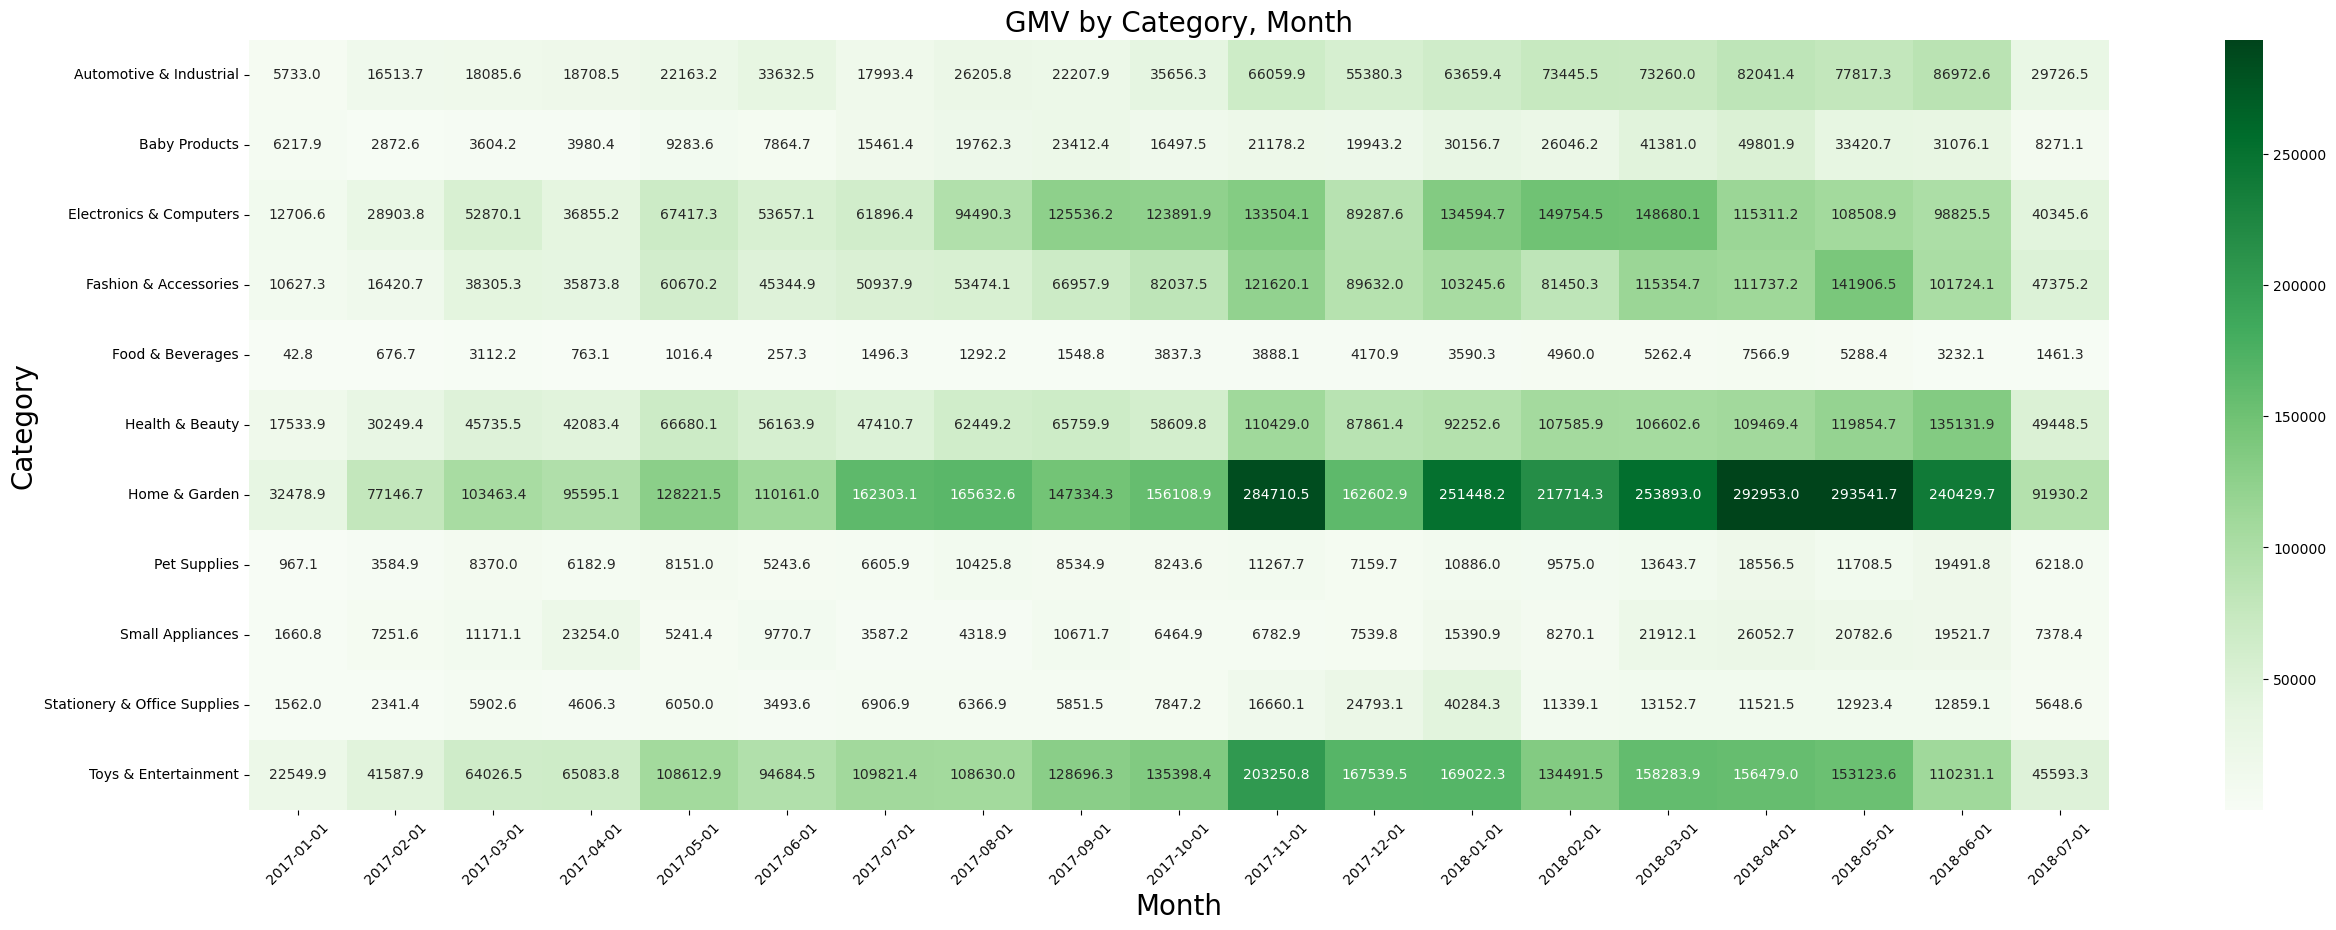

In [102]:
#GMV в разрезе по месяцам
plt.figure(figsize=(30, 10))
sns.heatmap(df3_pivot, annot=True, fmt=".1f", cmap="Greens")
plt.ylabel('Category', fontsize=20)
plt.xlabel('Month', fontsize=20)
plt.title('GMV by Category, Month', fontsize=20)
plt.xticks(rotation=45)
plt.show()

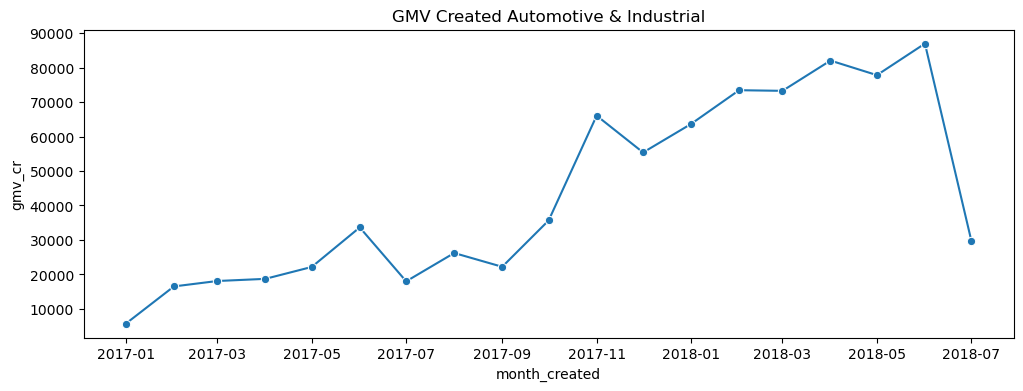

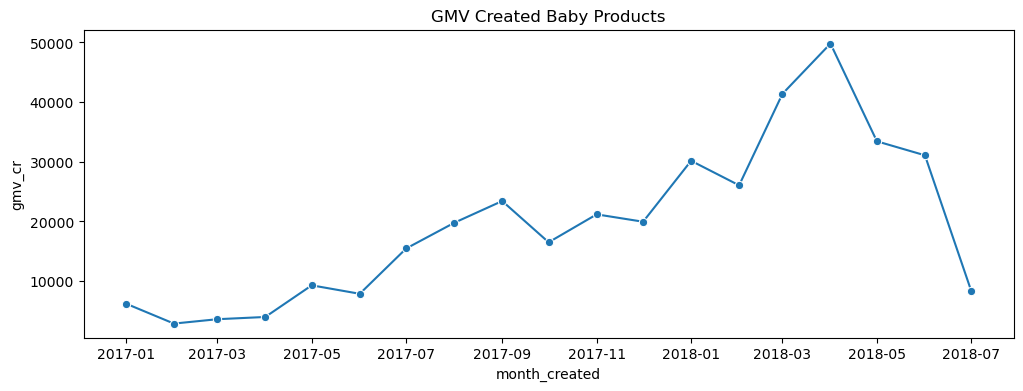

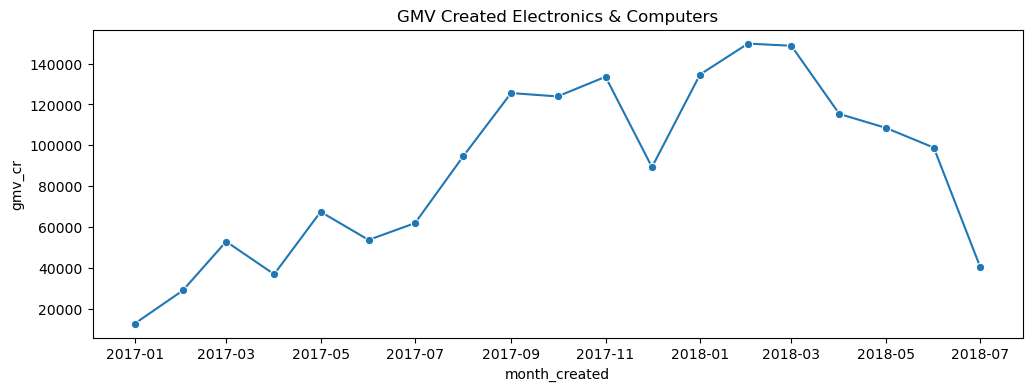

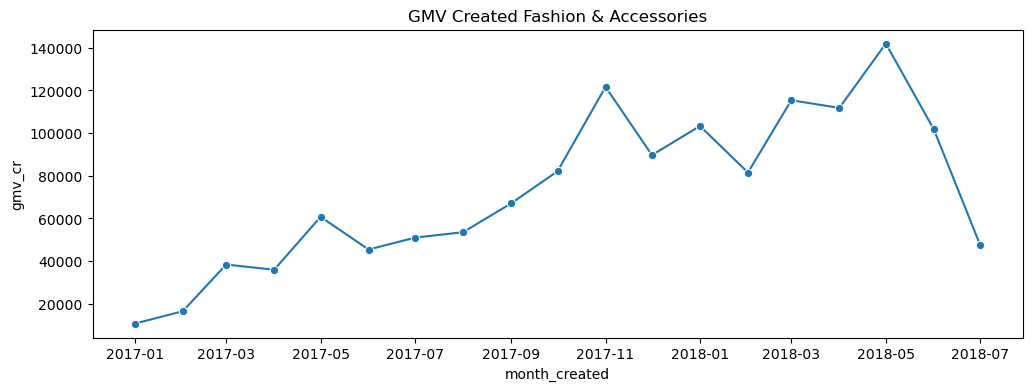

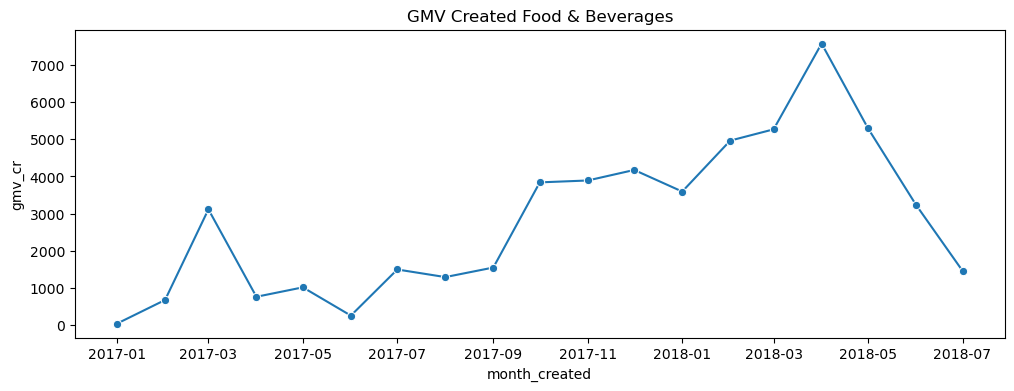

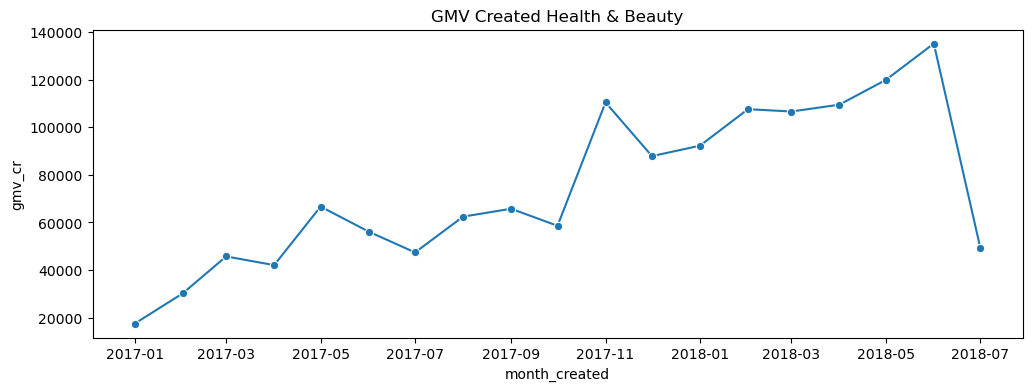

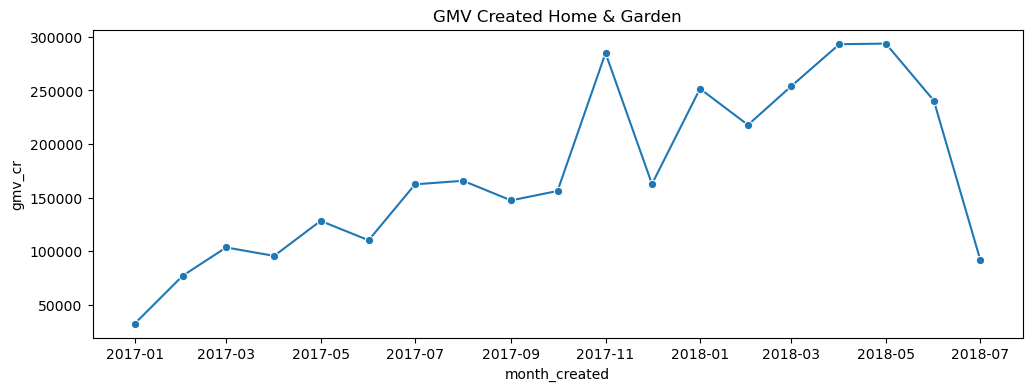

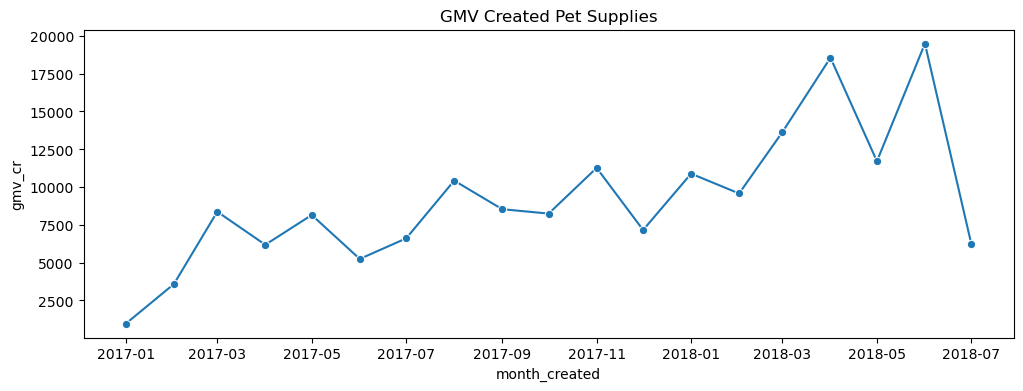

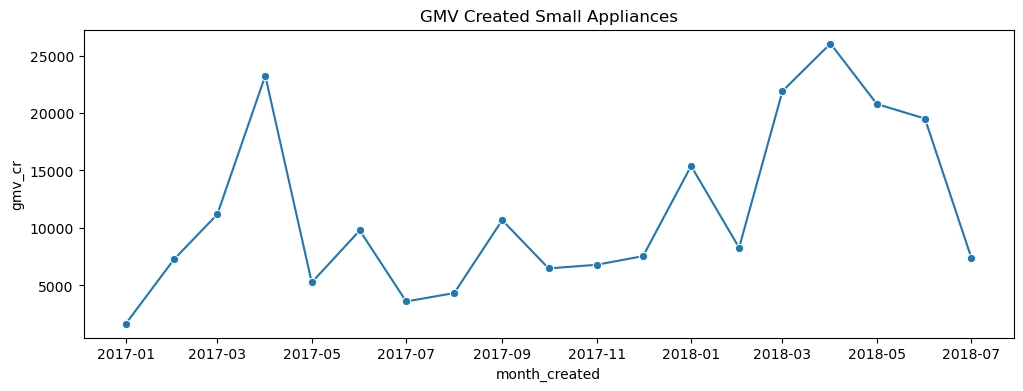

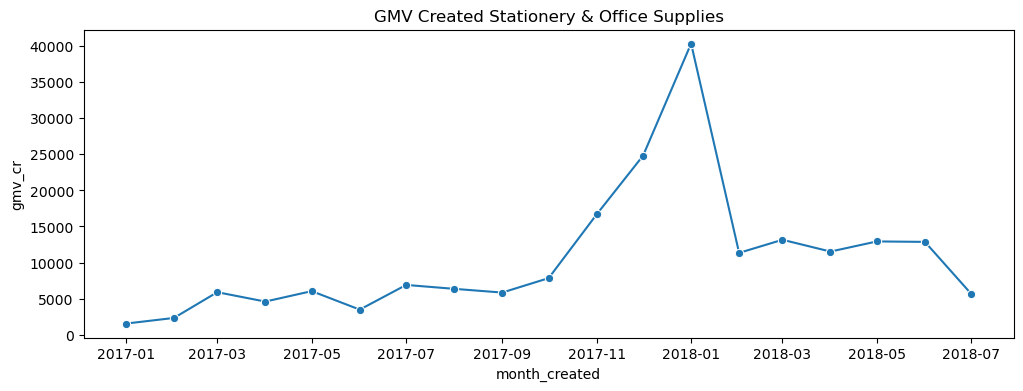

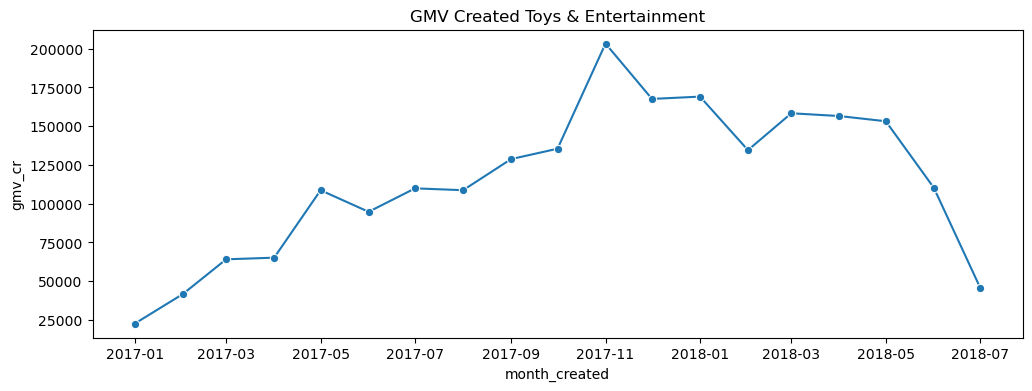

In [103]:
# GMV по категориям, отдельные графики
for i in df3_monthly.category_name.unique():
    plt.figure(figsize=(12, 4))
    sns.lineplot(data=df3_monthly[df3_monthly['category_name'] == i], x='month_created', y='gmv_cr', marker='o')
    plt.title(f'GMV Created {i}')   
    plt.show()

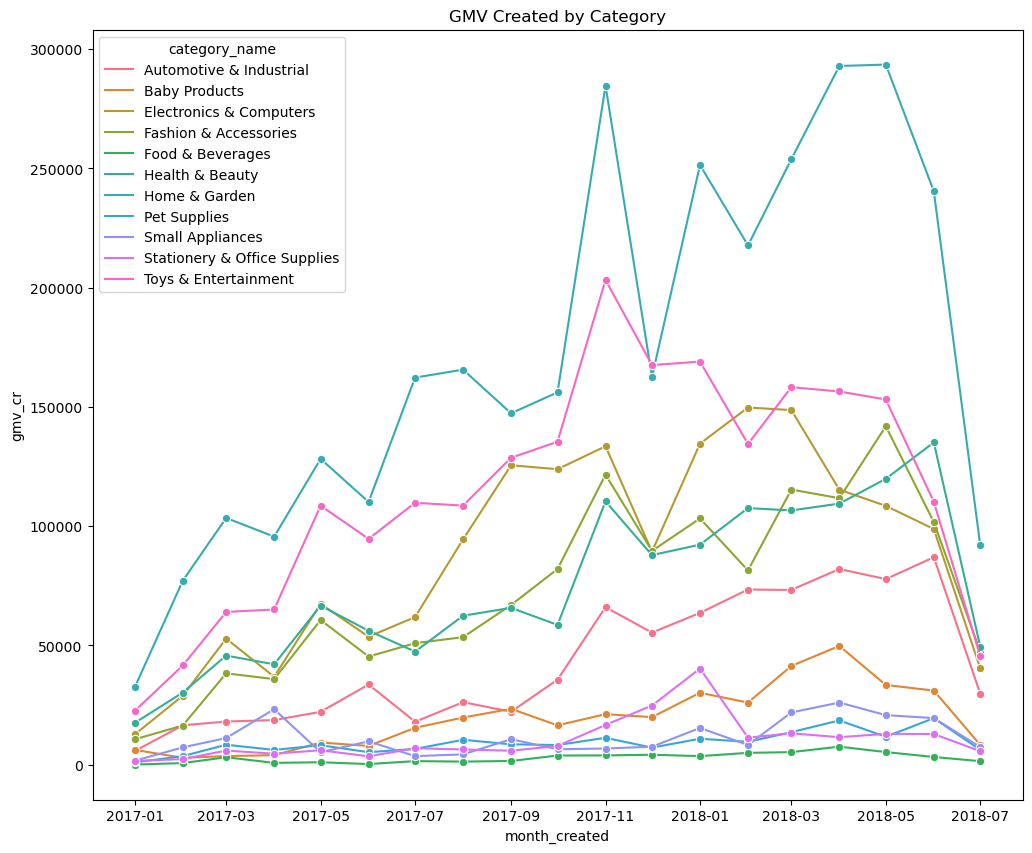

In [130]:
# GMV по категориям, на одном графике
plt.figure(figsize=(12, 10))
sns.lineplot(data=df3_monthly, x='month_created', y='gmv_cr', marker='o', hue='category_name')
plt.title(f'GMV Created by Category')   
plt.show()